Importing the Dependencies

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
(303, 13)
(303,)
Training set size: 242
Test set size: 61
Accuracy on Training data : 0.8554
Accuracy on Test data : 0.7869
Good: Training-test gap is only 0.0685

Cross-Validation Scores: [0.79591837 0.85714286 0.83333

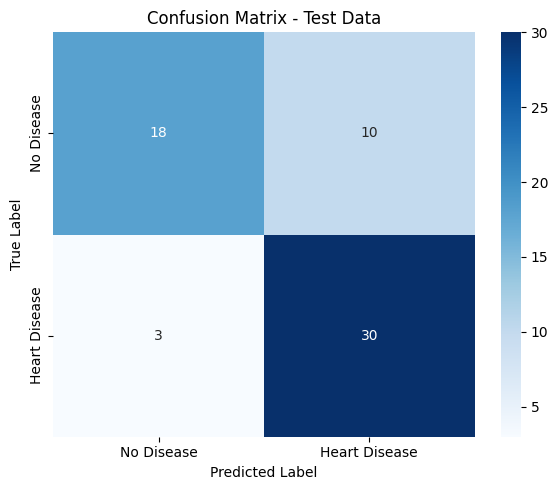


Classification Report:

               precision    recall  f1-score   support

   No Disease       0.86      0.64      0.73        28
Heart Disease       0.75      0.91      0.82        33

     accuracy                           0.79        61
    macro avg       0.80      0.78      0.78        61
 weighted avg       0.80      0.79      0.78        61


HYPERPARAMETER TUNING TO OPTIMIZE REGULARIZATION
Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Best cross-validation score: 0.8473

Best Model - Training Accuracy: 0.8554
Best Model - Test Accuracy: 0.7869
Training-Test Gap: 0.0685

Prediction: 0
Prediction Probabilities: No Disease: 84.52%, Heart Disease: 15.48%
The Person does not have a Heart Disease

FEATURE IMPORTANCE (Coefficients)
↑ cp: 0.6756
↓ sex: -0.4726
↓ thal: -0.4718
↓ oldpeak: -0.4405
↓ ca: -0.4174
↓ exang: -0.3962
↑ thalach: 0.3799
↑ slope: 0.2861
↓ chol: -0.2684
↑ restecg: 0.1604
↓ trestbps: -0.1371
↓ age: -0.0659
↓ fbs: -0.0243


In [1]:
# Importing the Dependencies
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Data Collection and Processing
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('../data/heart_disease_data.csv')

# print first 5 rows of the dataset
heart_data.head()

# print last 5 rows of the dataset
heart_data.tail()

# number of rows and columns in the dataset
heart_data.shape

# getting some info about the data
heart_data.info()

# checking for missing values
heart_data.isnull().sum()

# statistical measures about the data
heart_data.describe()

# checking the distribution of Target Variable
heart_data['target'].value_counts()

# 1 --> Defective Heart
# 0 --> Healthy Heart

# Splitting the Features and Target
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

print(X.shape)
print(Y.shape)

# Splitting the Data into Training data & Test Data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Feature Scaling - Important for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training with Regularization to prevent overfitting

# Option 1: Simple Logistic Regression with balanced class weight and stronger regularization
model = LogisticRegression(
    C=0.1,           # Stronger regularization (smaller C = more regularization)
    class_weight='balanced',  # Handle class imbalance
    max_iter=1000, 
    random_state=42,
    solver='liblinear'  # Good for smaller datasets
)

# training the model with scaled data
model.fit(X_train_scaled, Y_train)

# Model Evaluation with Cross-Validation to detect overfitting

# accuracy on training data
X_train_prediction = model.predict(X_train_scaled)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

# accuracy on test data
X_test_prediction = model.predict(X_test_scaled)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

print(f'Accuracy on Training data : {training_data_accuracy:.4f}')
print(f'Accuracy on Test data : {test_data_accuracy:.4f}')

# Check for overfitting (if training accuracy is much higher than test accuracy)
overfitting_gap = training_data_accuracy - test_data_accuracy
if overfitting_gap > 0.1:
    print(f"WARNING: Possible overfitting detected! Gap: {overfitting_gap:.4f}")
else:
    print(f"Good: Training-test gap is only {overfitting_gap:.4f}")

# Cross-Validation Score - More reliable performance estimate
cv_scores = cross_val_score(model, X_train_scaled, Y_train, cv=5)
print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Confusion Matrix for Test Data
cm = confusion_matrix(Y_test, X_test_prediction)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Data')
plt.tight_layout()
plt.show()

print('\nClassification Report:\n')
print(classification_report(Y_test, X_test_prediction, target_names=['No Disease', 'Heart Disease']))

# Option 2: Hyperparameter Tuning to find best regularization
print("\n" + "="*50)
print("HYPERPARAMETER TUNING TO OPTIMIZE REGULARIZATION")
print("="*50)

param_grid = {
    'C': [0.01, 0.05, 0.1, 0.5, 1, 10],  # Regularization strength
    'penalty': ['l1', 'l2'],  # L1 = Lasso, L2 = Ridge
    'solver': ['liblinear', 'saga']  # Solvers that support both penalties
}

grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, Y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Train best model
best_model = grid_search.best_estimator_
best_model.fit(X_train_scaled, Y_train)

# Evaluate best model
best_train_pred = best_model.predict(X_train_scaled)
best_test_pred = best_model.predict(X_test_scaled)

best_train_acc = accuracy_score(Y_train, best_train_pred)
best_test_acc = accuracy_score(Y_test, best_test_pred)

print(f"\nBest Model - Training Accuracy: {best_train_acc:.4f}")
print(f"Best Model - Test Accuracy: {best_test_acc:.4f}")
print(f"Training-Test Gap: {best_train_acc - best_test_acc:.4f}")

# Building a Predictive System with the best model
input_data = (62, 0, 0, 140, 268, 0, 0, 160, 0, 3.6, 0, 2, 2)

# change the input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Scale the input data using the same scaler
input_data_scaled = scaler.transform(input_data_reshaped)

prediction = best_model.predict(input_data_scaled)
prediction_proba = best_model.predict_proba(input_data_scaled)

print(f"\nPrediction: {prediction[0]}")
print(f"Prediction Probabilities: No Disease: {prediction_proba[0][0]:.2%}, Heart Disease: {prediction_proba[0][1]:.2%}")

if prediction[0] == 0:
    print('The Person does not have a Heart Disease')
else:
    print('The Person has Heart Disease')

# Feature Importance Analysis
print("\n" + "="*50)
print("FEATURE IMPORTANCE (Coefficients)")
print("="*50)

feature_names = X.columns
coefficients = best_model.coef_[0]

# Sort features by absolute coefficient value
feature_importance = sorted(zip(feature_names, coefficients), key=lambda x: abs(x[1]), reverse=True)

for feature, coef in feature_importance:
    direction = "↑" if coef > 0 else "↓"
    print(f"{direction} {feature}: {coef:.4f}")